# From autoencoders to sparse autoencoders — the combined primer

*Parts 0 and 1 in one sitting.* This notebook is the self-contained route into the SAE
speedrun: it assumes no autoencoder background, builds every concept from scratch, and ends
with a trained SAE verified against ground truth, plus the metrics used to grade one. (It
merges the [Part 0 primer](00_autoencoders_from_scratch.ipynb) and
[Part 1](01_superposition_and_saes.ipynb) — read it *instead of* those two, then continue
with [Part 2 · architectures & JumpReLU](02_architectures_jumprelu.ipynb).)

The series' concrete target is a single dashboard:
[**`gemma-3-1b / layer-13 / gemmascope-2-res-16k / latent 7447`**](https://www.neuronpedia.org/gemma-3-1b/13-gemmascope-2-res-16k/7447)
— a **"fruit" feature**. By the end of the series you'll know what every panel on that page
means, how it's computed, and how the SAE behind it was trained.

The route, in order:

1. **The claim that motivates everything** → the *linear representation hypothesis*: features
   are directions, activations are sparse sums of them — and finding the dictionary is the goal.
2. **The simplest autoencoder, a linear bottleneck** → squared-error training is exactly PCA
   (derived from scratch, proof skippable) — and why a linear map can never exploit sparsity.
3. **How does a ReLU enable superposition?** → a hand-built 2-features-in-1-dimension toy:
   sparsity plus a nonlinearity beats the rank limit, paying only when features co-fire.
4. **Learning the geometry** → the classic 5-features-in-2-dimensions toy *trained for real*:
   watch a pentagon of shared directions emerge on its own.
5. **How is an SAE different?** → the machine up front, then the whole round trip with
   hand-checkable numbers (cat, dog, French, CAPS) — plus a preview of JumpReLU.
6. **Proving it** → train a ReLU SAE against a known dictionary, watch it recover the
   features, and meet the metrics (L0, FVU, loss recovered) that grade every SAE.

Everything runs on CPU in about a minute. The real Gemma 3 work starts in
[Part 3](03_neuronpedia_dashboard.ipynb).


# Features, and the linear representation hypothesis

A **feature** is a property of the input that a model has learned to represent — "this text
is in French", "the current token is a fruit", "we're inside a parenthetical". The
**linear representation hypothesis** says these features are encoded as **directions** in a
model's activation space: feature $i$ has some unit vector $\mathbf{d}_i \in \mathbb{R}^{d}$,
and the activation vector for a given token is (approximately) a sparse weighted sum

$$\mathbf{x} \;\approx\; \mathbf{b} + \sum_i a_i\, \mathbf{d}_i,\qquad a_i \ge 0,\ \text{most } a_i = 0.$$

The scalar $a_i$ is *how strongly* feature $i$ is present. If this picture is right, then
understanding a model means finding the dictionary $\{\mathbf{d}_i\}$ and reading off which
features fire where. That is *exactly* what an SAE tries to do.

The catch: the model's natural basis — its individual neurons — is **not** the dictionary.
A single neuron typically responds to many unrelated features (it is *polysemantic*), and a
single feature is typically spread across many neurons. The reason is **superposition**.

The rest of this notebook builds up to un-mixing that superposition — with autoencoders. Two
of them, in fact, and they look confusingly alike; here they are side by side before we start.


# Two Networks That Look Alike

An autoencoder is one of the oldest ideas in representation learning: squeeze data
through a narrow channel and force it to come out the other side intact. A **sparse
autoencoder** — the tool this series is about — reuses that architecture almost verbatim,
and then inverts the point of it.

Putting them side by side is the fastest way to see what changes. Here is where we are
going — don't worry about decoding every label yet; the whole notebook builds up to this
picture, and we return to it at the end.

<figure style="margin:1.8rem auto;max-width:1000px">
  <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(330px,1fr));
              gap:1.2rem 1.8rem;align-items:start">
    <div>
<svg viewBox="0 0 420 330" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Undercomplete autoencoder: five inputs compressed to a two-unit bottleneck and reconstructed.</title>
<line x1="83" y1="130" x2="194" y2="147" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="130" x2="194" y2="189" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="168" x2="194" y2="147" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="168" x2="194" y2="189" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="244" x2="194" y2="147" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="244" x2="194" y2="189" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="92" x2="194" y2="147" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="92" x2="194" y2="189" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="194" y2="147" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="194" y2="189" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="226" y1="147" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.17"/>
<text x="210" y="20" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">Undercomplete autoencoder</text>
<text x="210" y="38" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">compresses: 5 → 2 → 5</text>
<text x="140" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">encoder E</text>
<text x="280" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">decoder D</text>
<circle cx="70" cy="92" r="11" fill="#f08c00"/>
<circle cx="70" cy="130" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="70" cy="168" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="70" cy="206" r="11" fill="#f08c00"/>
<circle cx="70" cy="244" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="147" r="14" fill="#4c8dd6"/>
<circle cx="210" cy="189" r="14" fill="#4c8dd6"/>
<circle cx="350" cy="92" r="11" fill="#f08c00" fill-opacity="0.42"/>
<circle cx="350" cy="130" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="350" cy="168" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="350" cy="206" r="11" fill="#f08c00" fill-opacity="0.42"/>
<circle cx="350" cy="244" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<text x="70" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">input x</text>
<text x="70" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">5 numbers</text>
<text x="210" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">bottleneck h</text>
<text x="210" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">squeezed to 2</text>
<text x="350" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">reconstruction x̂</text>
<text x="350" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">back to 5</text>
</svg>
    </div>
    <div>
<svg viewBox="0 0 420 330" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Sparse autoencoder: a five-dimensional dense activation expanded into nine latents, only two of which are active, then reconstructed.</title>
<line x1="83" y1="92" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="92" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="130" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="130" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="168" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="168" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="244" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="244" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="76" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="122" x2="337" y2="92" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="130" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="168" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="206" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="244" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="92" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="130" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="168" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="206" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="244" stroke="#f08c00" stroke-opacity="0.34"/>
<text x="210" y="20" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">Sparse (overcomplete) autoencoder</text>
<text x="210" y="38" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">expands: 5 → 9 → 5, but z is sparse</text>
<text x="136" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">encoder W<tspan font-size="9.5" dy="3">enc</tspan><tspan dy="-3">, ReLU</tspan></text>
<text x="286" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">decoder W<tspan font-size="9.5" dy="3">dec</tspan><tspan dy="-3"></tspan></text>
<circle cx="70" cy="92" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="130" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="168" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="206" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="244" r="11" fill="#4c8dd6"/>
<circle cx="210" cy="76" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="99" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="122" r="8" fill="#f08c00"/>
<circle cx="210" cy="145" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="168" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="191" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="214" r="8" fill="#f08c00"/>
<circle cx="210" cy="237" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="260" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="350" cy="92" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="130" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="168" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="206" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="244" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<text x="70" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">dense activation h</text>
<text x="70" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">the SAE reads this</text>
<text x="210" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">latents z</text>
<text x="210" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">9 latents, only 2 active</text>
<text x="350" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">reconstruction ĥ</text>
<text x="350" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">≈ h</text>
</svg>
    </div>
  </div>
  <div style="display:flex;flex-wrap:wrap;justify-content:center;gap:0.4rem 1.4rem;
              font-size:0.82em;opacity:0.75;margin-top:0.9rem">
    <span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="#f08c00" fill-opacity="1"/></svg>active sparse feature</span><span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="#4c8dd6" fill-opacity="1"/></svg>dense / mixed activation</span><span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="currentColor" fill-opacity="0" stroke="currentColor" stroke-opacity="0.5"/></svg>zero (inactive)</span><span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="26" height="13" viewBox="0 0 26 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="#f08c00" fill-opacity="0.42"/><circle cx="19.5" cy="6.5" r="5.5" fill="#4c8dd6" fill-opacity="0.42"/></svg>reconstructed (approximate)</span>
  </div>
  <figcaption style="font-size:0.9em;opacity:0.75;margin-top:0.9rem;
                     max-width:70ch;margin-left:auto;margin-right:auto;text-align:left">
    <strong>Left:</strong> the classical autoencoder squeezes its input through a narrower
    bottleneck, so it has no choice but to mix features together to survive the squeeze.
    <strong>Right:</strong> the sparse autoencoder runs the same machinery backwards: its
    input is already a dense mixture, its middle layer is <em>wider</em> than its input,
    and what limits it is not a shortage of dimensions but a sparsity constraint — all but
    a handful of latents must be zero. Highlighted edges show the subnetwork
    actually carrying signal.
  </figcaption>
</figure>


# The simplest autoencoder: an undercomplete linear autoencoder

The simplest autoencoder is **linear** — encoder and decoder are just matrices — and
**undercomplete** — the latent dimension is smaller than the input, $m < n$. Like every
autoencoder, it is trained to reconstruct its own input. The encoder squeezes
$x \in \mathbb{R}^n$ down to $h \in \mathbb{R}^m$; the decoder maps it back up:

$$
\underbrace{h = Ex}_{\text{encode}},
\qquad
\underbrace{\hat{x} = Dh}_{\text{decode}},
\qquad
E \in \mathbb{R}^{m \times n},\;
D \in \mathbb{R}^{n \times m}.
$$

The whole map is therefore $\hat{x} = DEx = Ax$, with $A = DE \in \mathbb{R}^{n\times n}$:

$$
\mathbb{R}^n \xrightarrow{\;E\;} \mathbb{R}^m \xrightarrow{\;D\;} \mathbb{R}^n .
$$

<figure style="margin:1.4rem auto;text-align:center;max-width:620px">
<svg viewBox="0 0 640 300" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Undercomplete linear autoencoder: a five-dimensional input is encoded to two numbers and decoded back to five.</title>
<line x1="106" y1="55" x2="307" y2="122" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="55" x2="307" y2="167" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="100" x2="307" y2="122" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="100" x2="307" y2="167" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="145" x2="307" y2="122" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="145" x2="307" y2="167" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="190" x2="307" y2="122" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="190" x2="307" y2="167" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="235" x2="307" y2="122" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="106" y1="235" x2="307" y2="167" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="122" x2="534" y2="55" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="122" x2="534" y2="100" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="122" x2="534" y2="145" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="122" x2="534" y2="190" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="122" x2="534" y2="235" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="167" x2="534" y2="55" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="167" x2="534" y2="100" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="167" x2="534" y2="145" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="167" x2="534" y2="190" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="333" y1="167" x2="534" y2="235" stroke="currentColor" stroke-opacity="0.15"/>
<circle cx="95" cy="55" r="11" fill="#4c8dd6"/>
<circle cx="95" cy="100" r="11" fill="#4c8dd6"/>
<circle cx="95" cy="145" r="11" fill="#4c8dd6"/>
<circle cx="95" cy="190" r="11" fill="#4c8dd6"/>
<circle cx="95" cy="235" r="11" fill="#4c8dd6"/>
<circle cx="320" cy="122" r="13" fill="#4c8dd6"/>
<circle cx="320" cy="167" r="13" fill="#4c8dd6"/>
<circle cx="545" cy="55" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="545" cy="100" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="545" cy="145" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="545" cy="190" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="545" cy="235" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<text x="207" y="40" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">encoder E</text>
<text x="432" y="40" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">decoder D</text>
<text x="95" y="268" text-anchor="middle" font-size="13" fill="currentColor">x ∈ ℝⁿ</text>
<text x="95" y="285" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.62">n = 5</text>
<text x="320" y="268" text-anchor="middle" font-size="13" fill="currentColor">h = Ex ∈ ℝᵐ</text>
<text x="320" y="285" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.62">m = 2 — the bottleneck</text>
<text x="545" y="268" text-anchor="middle" font-size="13" fill="currentColor">x̂ = Dh</text>
<text x="545" y="285" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.62">stuck inside col(D)</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.4rem;
                   max-width:64ch;margin-left:auto;margin-right:auto;text-align:left">
All information passes through <em>m</em> = 2 numbers, so the composite
<em>A</em> = <em>DE</em> has rank at most <em>m</em> — and every reconstruction is a mix of
<em>D</em>'s two columns, i.e. the model rebuilds <em>everything</em> from one shared
2-dimensional subspace.
</figcaption>
</figure>

Although $A$ maps an $n$-dimensional input to an $n$-dimensional output, everything passes
through the $m$-dimensional bottleneck, so $\operatorname{rank}(A) \leq m$. The decoder's side
tells the same story: every reconstruction $\hat{x} = Dh$ is a linear combination of the $m$
columns of $D$, so every possible output lies in the column space $\operatorname{col}(D)$ — a
single shared subspace of dimension at most $m$, reused for every input.

Training means choosing $E$ and $D$ — equivalently, choosing a linear map $A = DE$ of rank at
most $m$ — to minimise the average squared reconstruction error:

$$
\min_{\operatorname{rank}(A)\leq m}\;
\mathbb{E}_{x}\big[\lVert x - Ax \rVert_2^2\big].
$$

In other words: the linear autoencoder looks for the best $m$-dimensional linear subspace in
which to reconstruct the data.


## Linear autoencoders recover the principal components

> **Skippable proof.** The takeaway: **training a linear bottleneck autoencoder is exactly
> PCA** — it keeps the $m$ directions of greatest variance and projects onto them, the best
> any rank-$m$ map can do. Skim the pictures and the boxed result if you'd rather not derive it.

Which subspace wins? A projection's error is whatever spread lies **perpendicular** to the
subspace it keeps — so keep the directions where the data varies *most*. Those directions are
the **principal components**, and rank reduction is exactly why they matter.

Concretely, here is the machine we're claiming is optimal for $m = 1$: the smallest
autoencoder in this notebook, whose encoder row and decoder column are the *same* unit
vector $u_1$, the top principal direction —

<figure style="margin:1.2rem auto;text-align:center;max-width:420px">
<svg viewBox="0 0 440 216" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>A two-to-one-to-two linear autoencoder whose encoder row and decoder column are the top principal direction.</title>
<line x1="94" y1="58" x2="206" y2="98" stroke="currentColor" stroke-opacity="0.35"/>
<line x1="94" y1="148" x2="206" y2="108" stroke="currentColor" stroke-opacity="0.35"/>
<line x1="234" y1="98" x2="346" y2="58" stroke="currentColor" stroke-opacity="0.35"/>
<line x1="234" y1="108" x2="346" y2="148" stroke="currentColor" stroke-opacity="0.35"/>
<circle cx="80" cy="58" r="13" fill="#4c8dd6"/>
<circle cx="80" cy="148" r="13" fill="#4c8dd6"/>
<circle cx="220" cy="103" r="15" fill="#f08c00"/>
<circle cx="360" cy="58" r="13" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="360" cy="148" r="13" fill="#4c8dd6" fill-opacity="0.42"/>
<text x="46" y="63" text-anchor="middle" font-size="13" fill="currentColor">x₁</text>
<text x="46" y="153" text-anchor="middle" font-size="13" fill="currentColor">x₂</text>
<text x="220" y="136" text-anchor="middle" font-size="12" fill="currentColor">h = u₁ᵀx</text>
<text x="220" y="152" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">the PC1 coordinate</text>
<text x="394" y="63" text-anchor="middle" font-size="13" fill="currentColor">x̂₁</text>
<text x="394" y="153" text-anchor="middle" font-size="13" fill="currentColor">x̂₂</text>
<text x="150" y="62" text-anchor="middle" font-size="12" font-style="italic" fill="currentColor" opacity="0.72">E = u₁ᵀ</text>
<text x="290" y="62" text-anchor="middle" font-size="12" font-style="italic" fill="currentColor" opacity="0.72">D = u₁</text>
<text x="220" y="200" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.65">x̂ = u₁u₁ᵀx — project onto the top principal direction</text>
</svg>
</figure>

— and here is what it does to a data cloud, stage by stage:

<figure style="margin:1.4rem auto;text-align:center;max-width:900px">
<svg viewBox="0 0 960 356" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Pipeline: a 2-D cloud is encoded to one number per point along the top principal direction, then decoded back onto that line; the dashed errors are the spread perpendicular to it.</title>
<defs><marker id="arrF2" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="currentColor" fill-opacity="0.6"/></marker>
<marker id="arrO2" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="#f08c00"/></marker></defs>
<text x="480" y="22" text-anchor="middle" font-size="14" font-weight="600" fill="currentColor">The rank-1 autoencoder as a pipeline — and why u₁ is the best line</text>
<text x="150" y="58" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">1 · input cloud</text>
<circle cx="103" cy="242" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="113" cy="213" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="190" cy="170" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="166" cy="196" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="91" cy="220" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="140" cy="198" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="151" cy="203" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="107" cy="226" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="182" cy="177" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="101" cy="230" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="125" cy="186" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="157" cy="202" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="136" cy="193" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="154" cy="175" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="183" cy="179" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="215" cy="165" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="119" cy="208" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="165" cy="175" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="177" cy="180" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="122" cy="211" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="89" cy="245" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="217" cy="164" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="124" cy="212" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="130" cy="218" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="202" cy="163" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<circle cx="157" cy="181" r="3.4" fill="#4c8dd6" fill-opacity="0.6"/>
<line x1="150" y1="195" x2="212" y2="159" stroke="#f08c00" stroke-width="2.4" marker-end="url(#arrO2)"/>
<line x1="150" y1="195" x2="165" y2="221" stroke="currentColor" stroke-opacity="0.55" stroke-width="1.6" marker-end="url(#arrF2)"/>
<text x="224" y="146" text-anchor="start" font-size="10.5" fill="#f08c00">u₁ — most variance</text>
<text x="177" y="235" text-anchor="start" font-size="10.5" fill="currentColor" opacity="0.6">u₂ — little</text>
<text x="150" y="316" text-anchor="middle" font-size="12" fill="currentColor">x ∈ ℝ²</text>
<line x1="288" y1="190" x2="368" y2="190" stroke="currentColor" stroke-opacity="0.6" stroke-width="1.8" marker-end="url(#arrF2)"/>
<text x="328" y="172" text-anchor="middle" font-size="11.5" font-style="italic" fill="currentColor" opacity="0.75">encode</text>
<text x="328" y="210" text-anchor="middle" font-size="11.5" fill="currentColor">h = u₁ᵀx</text>
<text x="328" y="226" text-anchor="middle" font-size="10" fill="currentColor" opacity="0.6">(coordinate along u₁)</text>
<text x="475" y="58" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">2 · the code: one number per point</text>
<line x1="385" y1="195" x2="565" y2="195" stroke="currentColor" stroke-opacity="0.3"/>
<line x1="475" y1="190" x2="475" y2="200" stroke="currentColor" stroke-opacity="0.5"/>
<text x="475" y="216" text-anchor="middle" font-size="10" fill="currentColor" opacity="0.6">0</text>
<circle cx="410" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="434" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="522" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="488" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="412" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="465" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="472" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="422" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="512" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="415" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="458" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="478" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="464" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="489" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="512" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="546" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="441" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="498" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="506" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="443" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="397" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="549" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="444" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="446" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="536" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<circle cx="488" cy="195" r="3.4" fill="#4c8dd6" fill-opacity="0.55"/>
<text x="475" y="316" text-anchor="middle" font-size="12" fill="currentColor">h ∈ ℝ — the bottleneck</text>
<line x1="588" y1="190" x2="668" y2="190" stroke="currentColor" stroke-opacity="0.6" stroke-width="1.8" marker-end="url(#arrF2)"/>
<text x="628" y="172" text-anchor="middle" font-size="11.5" font-style="italic" fill="currentColor" opacity="0.75">decode</text>
<text x="628" y="210" text-anchor="middle" font-size="11.5" fill="currentColor">x̂ = u₁h</text>
<text x="628" y="226" text-anchor="middle" font-size="10" fill="currentColor" opacity="0.6">(rebuild along u₁)</text>
<text x="810" y="58" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">3 · reconstruction — stuck on the line</text>
<line x1="723" y1="245" x2="897" y2="145" stroke="#f08c00" stroke-opacity="0.5"/>
<line x1="785" y1="186" x2="795" y2="203" stroke="currentColor" stroke-opacity="0.5" stroke-dasharray="3 3"/>
<line x1="763" y1="242" x2="754" y2="227" stroke="currentColor" stroke-opacity="0.5" stroke-dasharray="3 3"/>
<line x1="814" y1="175" x2="822" y2="188" stroke="currentColor" stroke-opacity="0.5" stroke-dasharray="3 3"/>
<line x1="749" y1="245" x2="743" y2="234" stroke="currentColor" stroke-opacity="0.5" stroke-dasharray="3 3"/>
<line x1="790" y1="218" x2="785" y2="210" stroke="currentColor" stroke-opacity="0.5" stroke-dasharray="3 3"/>
<circle cx="763" cy="242" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="773" cy="213" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="850" cy="170" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="826" cy="196" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="751" cy="220" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="800" cy="198" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="811" cy="203" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="767" cy="226" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="842" cy="177" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="761" cy="230" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="785" cy="186" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="817" cy="202" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="796" cy="193" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="814" cy="175" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="843" cy="179" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="875" cy="165" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="779" cy="208" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="825" cy="175" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="837" cy="180" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="782" cy="211" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="749" cy="245" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="877" cy="164" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="784" cy="212" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="790" cy="218" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="862" cy="163" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="817" cy="181" r="3.4" fill="#4c8dd6" fill-opacity="0.14"/>
<circle cx="754" cy="227" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="774" cy="216" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="851" cy="172" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="821" cy="189" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="755" cy="227" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="801" cy="200" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="807" cy="197" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="764" cy="222" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="842" cy="177" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="758" cy="225" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="795" cy="203" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="812" cy="194" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="801" cy="200" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="822" cy="188" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="842" cy="176" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="872" cy="159" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="781" cy="212" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="830" cy="183" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="837" cy="180" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="782" cy="211" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="743" cy="234" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="874" cy="158" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="783" cy="211" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="785" cy="210" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="863" cy="164" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<circle cx="822" cy="188" r="3.4" fill="#f08c00" fill-opacity="0.85"/>
<text x="876" y="258" text-anchor="start" font-size="10" fill="currentColor" opacity="0.6">error x − x̂ ⊥ u₁</text>
<text x="810" y="316" text-anchor="middle" font-size="12" fill="currentColor">x̂ = u₁u₁ᵀx ∈ ℝ²</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem;max-width:72ch;margin-left:auto;margin-right:auto;text-align:left">
Encoding is a dot product: <em>h</em> = u₁ᵀ<em>x</em> keeps only each point's coordinate along
u₁ — one number. Decoding rebuilds x̂ = u₁<em>h</em>, so every reconstruction sits on the u₁
line, and the error <em>x</em> − x̂ (dashed) is exactly the component of <em>x</em>
perpendicular to it. Keeping the line with the <em>most</em> variance along it leaves the
<em>least</em> variance perpendicular to it — which is why the top principal component is
precisely the right direction to keep when you cut rank.
</figcaption>
</figure>

Now the same statement in matrices. One housekeeping step first: our autoencoder has no bias
terms, so every reconstruction $\hat x = Ax$ must pass through the origin — we simply
**centre** the data (subtract each feature's mean) so the cloud sits there. Store the centred
datapoints as the columns of $X \in \mathbb{R}^{n \times N}$; training then solves

$$
\min_{\operatorname{rank}(A)\leq m} \lVert X - AX\rVert_F^2
\qquad (A = DE,\ \text{rank} \leq m\ \text{because of the bottleneck}),
$$

with $\lVert\cdot\rVert_F$ the elementwise $L_2$ norm. Two standard facts, stated without proof:

1. Any matrix factors as $X = U\Sigma V^\top$ — the **SVD** — with orthonormal columns in $U$
   and $V$ and singular values $\sigma_1 \geq \sigma_2 \geq \dots$ on $\Sigma$'s diagonal.
   For centred data, the columns of $U$ are the **principal components**: the orthogonal
   directions of greatest variance, in decreasing order.
2. **Eckart–Young**: the closest rank-$m$ matrix to $X$ (in $\lVert\cdot\rVert_F$) is the
   truncated SVD, $X_m = U_m\Sigma_mV_m^\top$ — keep the top $m$ singular directions, drop
   the rest. ($U_m$ = first $m$ columns of $U$.)

### The proof, step by step

**Claim:** the optimal map is $A^* = U_mU_m^\top$ — project every point onto the span of the
top $m$ principal directions.

**Step 1: $A^*$ produces the truncated SVD.** Substitute $X = U\Sigma V^\top$:

$$
A^*X = U_m\,\underbrace{U_m^\top U}_{?}\,\Sigma V^\top .
$$

The matrix $U_m^\top U$ is filled with dot products between singular vectors — and they are
orthonormal, so each dot product is $1$ on a match and $0$ otherwise:

$$
U_m^\top U = [\,I_m \;\; 0\,]
\qquad\text{(a selector: keep the first } m \text{ rows, kill the rest)} .
$$

Applying that selector to $\Sigma V^\top$ leaves exactly the top-$m$ part:

$$
A^*X = U_m\,\Sigma_m V_m^\top = X_m .
$$

**Step 2: no admissible $A$ does better.** Any competitor satisfies
$\operatorname{rank}(A) \leq m$, and multiplying by $X$ cannot raise rank, so its output
$AX$ is *some* matrix of rank $\leq m$. But Eckart–Young says the closest such matrix to $X$
is $X_m$:

$$
\lVert X - AX\rVert_F \;\geq\; \lVert X - X_m\rVert_F \;=\; \lVert X - A^*X\rVert_F .
$$

Every competitor is bounded below by the value $A^*$ achieves — so $A^*$ is optimal.

$$
\boxed{\,A^* = U_mU_m^\top,\qquad A^*X = X_m\,}
$$

One optimal split is $E = U_m^\top$, $D = U_m$ (**tied weights**, $D = E^\top$ — one matrix,
both directions; we reuse this next section). The split isn't unique — any invertible $R$
gives $E = RU_m^\top$, $D = U_mR^{-1}$ with the same product — so reconstruction alone cannot
pin down a basis *inside* the bottleneck. Hold that thought: an SAE faces the same freedom,
and it is *sparsity* that breaks the tie.

### Seeing it

The theorem says the network above — encoder $u_1^\top$, decoder $u_1$ — is what training
*should* find. So check it both ways on a synthetic cloud: compute $u_1$ from the SVD, *and*
train a $2 \to 1 \to 2$ linear autoencoder from random weights with plain gradient descent —
then compare the direction the trained decoder learned against $u_1$.


In [ ]:
import numpy as np, matplotlib.pyplot as plt, torch
torch.manual_seed(0)
rng = np.random.default_rng(0)

# a centred 2-D cloud with lots of variance along one diagonal, little across it
X = rng.normal(size=(2, 200)) * np.array([[2.0], [0.45]])
th = np.deg2rad(30)
X = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]]) @ X

# 1) the closed-form answer: u1 from the SVD
u1 = np.linalg.svd(X, full_matrices=False)[0][:, :1]
X_pca = u1 @ (u1.T @ X)                              # x̂ = u1 u1ᵀ x

# 2) the trained answer: a 2 -> 1 -> 2 linear autoencoder, plain MSE, random init
Xt = torch.tensor(X.T, dtype=torch.float32)
E = torch.nn.Linear(2, 1, bias=False)                # h  = E x
D = torch.nn.Linear(1, 2, bias=False)                # x̂ = D h
opt = torch.optim.Adam([*E.parameters(), *D.parameters()], lr=0.02)
for _ in range(800):
    loss = ((Xt - D(E(Xt))) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

d = D.weight.detach().numpy(); d /= np.linalg.norm(d)   # the trained decoder's direction
fvu = lambda Xh: ((X - Xh) ** 2).sum() / (X ** 2).sum()
X_ae = D(E(Xt)).detach().numpy().T
print(f"cosine(trained direction, u1) = {abs((d.T @ u1).item()):.5f}")
print(f"variance lost — SVD: {fvu(X_pca):.2%},  trained autoencoder: {fvu(X_ae):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), sharex=True, sharey=True)

ax = axes[0]                                         # what goes IN
ax.scatter(*X, s=14, color="#4c8dd6", alpha=0.55)
ax.set_aspect("equal"); ax.grid(alpha=0.25, ls=":")
ax.set_title("input: the data $x$", fontsize=11)

ax = axes[1]                                         # what comes OUT
ax.scatter(*X, s=14, color="#4c8dd6", alpha=0.12, label="input (for reference)")
ax.scatter(*X_pca, s=16, color="#f08c00", alpha=0.9, label=r"reconstructions $\hat{x} = u_1 u_1^\top x$")
for i in range(0, 200, 12):                          # where a few points came from
    ax.plot([X[0, i], X_pca[0, i]], [X[1, i], X_pca[1, i]], color="0.65", lw=0.7, zorder=0)
ax.axline((0.0, 0.0), tuple(u1.ravel()), color="#f08c00", lw=1, alpha=0.6)
ax.axline((0.0, 0.0), tuple(d.ravel()), color="0.25", lw=1.4, ls="--", label="trained AE direction")
ax.set_aspect("equal"); ax.grid(alpha=0.25, ls=":")
ax.legend(loc="upper left", fontsize=9)
ax.set_title(r"output: every $\hat{x}$ collapses onto one line", fontsize=11)

fig.suptitle("SVD and gradient descent find the same line", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

Gradient descent and the SVD find the same line, and no line does better:

$$
\boxed{
\text{undercomplete linear autoencoder}
\quad\Longleftrightarrow\quad
\text{projection onto the principal-component subspace}
}
$$

A linear autoencoder can therefore never represent more features than it has bottleneck
dimensions. Beating that ceiling requires a nonlinearity — **superposition**, next.


# How do ReLUs enable superposition?

**Superposition** means storing more features than you have dimensions, by letting the
features share directions in activation space. We just proved a *linear* bottleneck cannot do
this — $\operatorname{rank}(A) \leq m$ — so something nonlinear has to give. Here is the
smallest possible example.

## The setup

A tiny tied-weight autoencoder: two input features squeezed through a **one-dimensional**
bottleneck and back out again.

$$
x_A,\, x_B \;\longrightarrow\; h \;\longrightarrow\; \hat{x}_A,\, \hat{x}_B
$$

$$
h = Wx, \qquad \hat{x} = W^\top h = W^\top W x
$$

<figure style="margin:1.4rem auto;text-align:center;max-width:440px">
<svg viewBox="0 0 460 250" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Two features squeezed through a one-dimensional bottleneck with tied weights plus one and minus one, then decoded back to two outputs.</title>
<line x1="94" y1="70" x2="216" y2="115" stroke="currentColor" stroke-opacity="0.35"/>
<line x1="94" y1="170" x2="216" y2="125" stroke="currentColor" stroke-opacity="0.35"/>
<line x1="244" y1="115" x2="366" y2="70" stroke="currentColor" stroke-opacity="0.35"/>
<line x1="244" y1="125" x2="366" y2="170" stroke="currentColor" stroke-opacity="0.35"/>
<circle cx="80" cy="70" r="13" fill="#f08c00"/>
<circle cx="80" cy="170" r="13" fill="#f08c00"/>
<circle cx="230" cy="120" r="15" fill="#4c8dd6"/>
<circle cx="380" cy="70" r="13" fill="#f08c00" fill-opacity="0.42"/>
<circle cx="380" cy="170" r="13" fill="#f08c00" fill-opacity="0.42"/>
<text x="48" y="75" text-anchor="middle" font-size="13" fill="currentColor">x<tspan font-size="10" dy="3">A</tspan></text>
<text x="48" y="175" text-anchor="middle" font-size="13" fill="currentColor">x<tspan font-size="10" dy="3">B</tspan></text>
<text x="230" y="153" text-anchor="middle" font-size="13" fill="currentColor">h</text>
<text x="416" y="75" text-anchor="middle" font-size="13" fill="currentColor">x̂<tspan font-size="10" dy="3">A</tspan></text>
<text x="416" y="175" text-anchor="middle" font-size="13" fill="currentColor">x̂<tspan font-size="10" dy="3">B</tspan></text>
<text x="148" y="78" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">+1</text>
<text x="148" y="162" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">−1</text>
<text x="312" y="78" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">+1</text>
<text x="312" y="162" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.8">−1</text>
<text x="155" y="222" text-anchor="middle" font-size="12" font-style="italic" fill="currentColor" opacity="0.7">h = Wx,&#160;&#160;W = [1&#160;&#160;−1]</text>
<text x="312" y="222" text-anchor="middle" font-size="12" font-style="italic" fill="currentColor" opacity="0.7">x̂ = Wᵀh&#160;&#160;(tied weights)</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.4rem">
Two features, <em>one</em> number in the middle. The same weights are used to encode
(+1, −1) and, transposed, to decode.
</figcaption>
</figure>

## Sparsity

Consider that our data is **sparse**: features $x_A$ and $x_B$ are rarely on at the same time
(they rarely "co-fire"). So in practice

$$
x \approx \begin{bmatrix} 1 \\ 0 \end{bmatrix}
\quad \text{or} \quad
\begin{bmatrix} 0 \\ 1 \end{bmatrix}
$$

In $x$-space the data lives (almost) entirely on the two axes.

## The bottleneck

Take $W = \begin{bmatrix} 1 & -1 \end{bmatrix}$:

$$
h = Wx = \begin{bmatrix} 1 & -1 \end{bmatrix}
\begin{bmatrix} x_A \\ x_B \end{bmatrix}
= x_A - x_B
$$

$$
x = \begin{bmatrix} 1 \\ 0 \end{bmatrix} \Rightarrow h = 1,
\qquad
x = \begin{bmatrix} 0 \\ 1 \end{bmatrix} \Rightarrow h = -1
$$

**The sign of $h$ tells us which feature is active.** The two features land at $+1$ and $-1$,
on opposite sides of the origin, and one scalar is carrying two features — that's the
superposition.


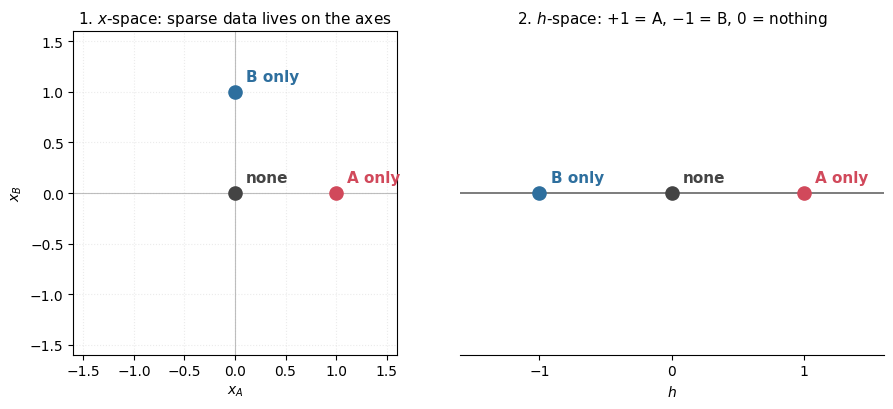

In [2]:
import numpy as np, matplotlib.pyplot as plt

W = np.array([[1.0, -1.0]])                       # the bottleneck: h = W x
labels = ["none", "A only", "B only"]              # sparse data: A and B never co-fire
X = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
colors = ["#444444", "#d1495b", "#2e6f9e"]
H = X @ W.T

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))

ax = axes[0]                                       # where the sparse data lives
ax.axhline(0, color="0.75", lw=0.8, zorder=0); ax.axvline(0, color="0.75", lw=0.8, zorder=0)
for lab, (px, py), c in zip(labels, X, colors):
    ax.scatter(px, py, s=90, color=c, zorder=3)
    ax.annotate(lab, (px, py), textcoords="offset points", xytext=(8, 8),
                color=c, fontsize=11, fontweight="bold")
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect("equal")
ax.set_xlabel("$x_A$"); ax.set_ylabel("$x_B$")
ax.set_title("1. $x$-space: sparse data lives on the axes", fontsize=11)
ax.grid(alpha=0.25, ls=":")

ax = axes[1]                                       # ...and where the bottleneck puts it
ax.axhline(0, color="0.4", lw=1.2, zorder=1)
for lab, v, c in zip(labels, H.ravel(), colors):
    ax.scatter(v, 0, s=90, color=c, zorder=3)
    ax.annotate(lab, (v, 0), textcoords="offset points", xytext=(8, 8),
                color=c, fontsize=11, fontweight="bold")
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.0, 1.0)
ax.set_yticks([]); ax.set_xticks([-1, 0, 1]); ax.set_xlabel("$h$")
ax.set_title("2. $h$-space: $+1$ = A, $-1$ = B, $0$ = nothing", fontsize=11)
ax.spines[["left", "right", "top"]].set_visible(False)

fig.tight_layout(); plt.show()

## The problem: interference

Because our weights are tied, $\hat{x} = W^\top W x$:

$$
\begin{bmatrix} \hat{x}_A \\ \hat{x}_B \end{bmatrix}
=
\begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}
\begin{bmatrix} x_A \\ x_B \end{bmatrix}
=
\begin{bmatrix} x_A - x_B \\ x_B - x_A \end{bmatrix}
$$

But this causes problems:

$$
x = \begin{bmatrix} 1 \\ 0 \end{bmatrix}
\;\Rightarrow\; h = 1
\;\Rightarrow\; \hat{x} = \begin{bmatrix} 1 \\ -1 \end{bmatrix}
\qquad \text{✗ wrong!}
$$

The $-1$ is an **interference** term: the decoder cannot help but read the "$A$ is on" signal
as "$B$ is negatively on". (The culprit is the rank-1 bottleneck itself, not the weight tying —
an untied linear decoder fails in exactly the same way.)

## The fix

A **ReLU** ("rectified linear unit") is the simplest nonlinearity there is:
$\operatorname{ReLU}(u) = \max(u, 0)$ — negative inputs become exactly zero, positive
inputs pass through untouched.

<figure style="margin:1rem auto;text-align:center;max-width:300px">
<svg viewBox="0 0 320 200" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>The ReLU function: zero for negative inputs, the identity for positive inputs.</title>
<text x="160" y="22" text-anchor="middle" font-size="12.5" font-weight="600" fill="currentColor">ReLU(u) = max(u, 0)</text>
<line x1="25" y1="150" x2="300" y2="150" stroke="currentColor" stroke-opacity="0.3"/>
<line x1="140" y1="188" x2="140" y2="38" stroke="currentColor" stroke-opacity="0.3"/>
<polyline points="30,150 140,150 255,35" fill="none" stroke="#4c8dd6" stroke-width="2.6"/>
<text x="85" y="168" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.65">negatives → 0</text>
<text x="252" y="55" text-anchor="end" font-size="10.5" fill="currentColor" opacity="0.65">positives unchanged</text>
<text x="308" y="155" text-anchor="start" font-size="11" fill="currentColor" opacity="0.6">u</text>
</svg>
</figure>

If we add one after our decoder:

$$
\mathrm{ReLU}\!\left(\begin{bmatrix} 1 \\ -1 \end{bmatrix}\right)
= \begin{bmatrix} 1 \\ 0 \end{bmatrix}
\qquad \text{✓ correct!}
$$

The interference lands on the *negative* side — not by luck, but by construction: we embedded
the two features at $+1$ and $-1$, pointing in opposite directions, precisely so that each
feature's bleed-through into the other comes out negative. (Trained toy models discover the
same antipodal arrangement on their own — we'll watch it happen for real in the pentagon experiment below.) Features themselves are
non-negative, so the nonlinearity clips the interference away:

$$
\hat{x} = \mathrm{ReLU}\left(W^\top W x\right)
$$

One detail makes the answer come out *exactly* right: the columns of $W$ have unit norm, so
the surviving coordinate is already at the correct scale. ReLU deletes negative interference —
it does not rescale what remains.

## Where it still breaks

| input | $x$ | $h = x_A - x_B$ | $\hat{x} = W^\top W x$ | $\hat{x} = \mathrm{ReLU}(W^\top W x)$ |
|---|---|---|---|---|
| none | $(0,0)$ | $0$ | $(0,0)$ ✓ | $(0,0)$ ✓ |
| $A$ only | $(1,0)$ | $+1$ | $(1,-1)$ ✗ | $(1,0)$ ✓ |
| $B$ only | $(0,1)$ | $-1$ | $(-1,1)$ ✗ | $(0,1)$ ✓ |
| both | $(1,1)$ | $0$ | $(0,0)$ ✗ | $(0,0)$ ✗ |

**ReLU is still wrong when features co-fire, but is correct otherwise.** The input $(1,1)$ is
indistinguishable from $(0,0)$ the moment it enters the bottleneck — $h = 0$ for both — and no
decoder can recover information that was destroyed upstream.

## Takeaway

When your features are sparse (they rarely co-fire), you can use a bottleneck to compress
them — but the compression creates interference. A ReLU removes the harmful *negative*
interference; what remains are the collisions, which only occur when features fire together.

**Get the causality straight:** the sparsity here was a property of the *data* — we assumed
features rarely co-fire. The ReLU does not *create* sparsity, and nothing about it makes
activations sparse on its own; it is what lets the model *exploit* sparsity that is already
there (and, inside an SAE later, what *permits* a latent to sit at exactly zero — the
sparsity itself will come from an explicit penalty). This distinction recurs at every level
of this notebook.


none   : x=[0. 0.]  h=+0  xhat_lin=[0. 0.]  xhat_relu=[0. 0.]
A only : x=[1. 0.]  h=+1  xhat_lin=[ 1. -1.]  xhat_relu=[1. 0.]
B only : x=[0. 1.]  h=-1  xhat_lin=[-1.  1.]  xhat_relu=[0. 1.]
both   : x=[1. 1.]  h=+0  xhat_lin=[0. 0.]  xhat_relu=[0. 0.]


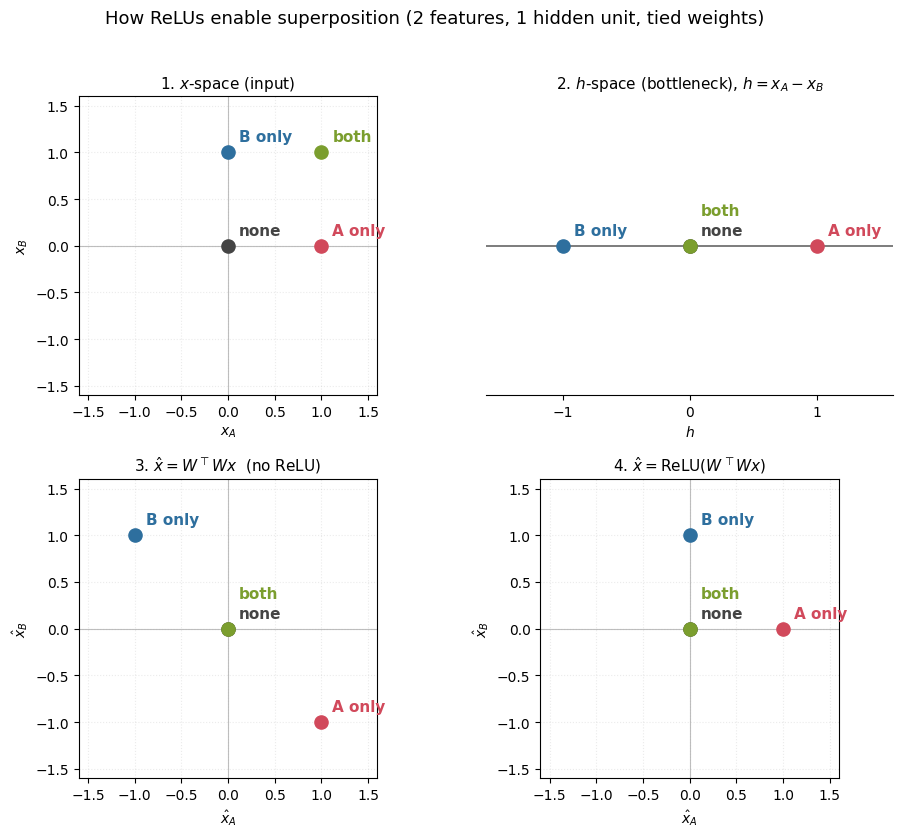

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# h    = W x            with W = [1, -1]
# xhat = W^T h          (linear)  or  ReLU(W^T h)
W = np.array([[1.0, -1.0]])          # shape (1, 2)

labels = ["none", "A only", "B only", "both"]
X = np.array([
    [0.0, 0.0],   # none:   nothing on
    [1.0, 0.0],   # A only: just feature x_A
    [0.0, 1.0],   # B only: just feature x_B
    [1.0, 1.0],   # both:   features co-fire, violates sparsity
])
colors = ["#444444", "#d1495b", "#2e6f9e", "#7b9e2e"]

H         = X @ W.T                  # (4, 1)  bottleneck code
Xhat_lin  = H @ W                    # (4, 2)  xhat = W^T W x
Xhat_relu = np.maximum(Xhat_lin, 0)  # (4, 2)  xhat = ReLU(W^T W x)

for lab, x, h, xl, xr in zip(labels, X, H, Xhat_lin, Xhat_relu):
    print(f"{lab:7s}: x={x}  h={h[0]:+.0f}  xhat_lin={xl}  xhat_relu={xr}")


def scatter2d(ax, pts, title, xlabel, ylabel):
    ax.axhline(0, color="0.75", lw=0.8, zorder=0)
    ax.axvline(0, color="0.75", lw=0.8, zorder=0)
    seen = {}
    for lab, (px, py), c in zip(labels, pts, colors):
        ax.scatter(px, py, s=90, color=c, zorder=3)
        k = (round(px, 6), round(py, 6))          # stack labels when points coincide
        seen[k] = seen.get(k, 0) + 1
        ax.annotate(lab, (px, py), textcoords="offset points",
                    xytext=(8, 8 + 14 * (seen[k] - 1)), color=c,
                    fontsize=11, fontweight="bold")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect("equal")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25, ls=":")


def scatter1d(ax, vals, title, xlabel):
    ax.axhline(0, color="0.4", lw=1.2, zorder=1)
    seen = {}
    for lab, v, c in zip(labels, vals.ravel(), colors):
        ax.scatter(v, 0, s=90, color=c, zorder=3)
        k = round(v, 6)
        seen[k] = seen.get(k, 0) + 1
        ax.annotate(lab, (v, 0), textcoords="offset points",
                    xytext=(8, 8 + 14 * (seen[k] - 1)), color=c,
                    fontsize=11, fontweight="bold")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.0, 1.0)
    ax.set_yticks([]); ax.set_xticks([-1, 0, 1])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    ax.spines[["left", "right", "top"]].set_visible(False)


fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.5))

scatter2d(axes[0, 0], X, "1. $x$-space (input)", "$x_A$", "$x_B$")
scatter1d(axes[0, 1], H, "2. $h$-space (bottleneck), $h = x_A - x_B$", "$h$")
scatter2d(axes[1, 0], Xhat_lin,
          r"3. $\hat{x} = W^\top W x$  (no ReLU)", r"$\hat{x}_A$", r"$\hat{x}_B$")
scatter2d(axes[1, 1], Xhat_relu,
          r"4. $\hat{x} = \mathrm{ReLU}(W^\top W x)$", r"$\hat{x}_A$", r"$\hat{x}_B$")

fig.suptitle("How ReLUs enable superposition (2 features, 1 hidden unit, tied weights)",
             fontsize=13, y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

Reading the panels left-to-right, top-to-bottom: the four inputs start out distinct
in $x$-space; the bottleneck collapses **none** and **both** onto the same value; the linear
decoder pushes **A only** and **B only** off-axis into negative-interference territory; and
the ReLU clips them back onto the correct axes, leaving only the none/both collision — the one
error that was baked in before the decoder ever ran.

We hand-picked $W$ for two features. Next, let a slightly bigger toy *learn* the same trick
on its own — five features, two dimensions — and watch the geometry the linear representation
hypothesis predicts actually emerge from training.


# Scaling the toy up: five features, two dimensions

Suppose a model would "like" to represent $n$ features but only has $m < n$ dimensions to
store them in. It cannot give every feature its own orthogonal axis. But if features are
**sparse** (rarely active) and the model tolerates a little interference, it can do
something clever: store the features as $n$ *non-orthogonal* directions crammed into $m$
dimensions. When only a few features are active at once, the interference between them is
usually small enough to recover the signal.

The classic demonstration (Anthropic's *Toy Models of Superposition*) is exactly the
tied-weight toy we just built by hand — but with the weights *learned*, and forced to
compress $n$ sparse features through an $m$-dimensional bottleneck:

$$\mathbf{h} = W\mathbf{x}\ \ (\text{compress to } m),\qquad
  \hat{\mathbf{x}} = \operatorname{ReLU}(W^\top \mathbf{h} + \mathbf{b})\ \ (\text{decompress}).$$

$W$ is $m \times n$. The columns of $W$ are the directions the model chooses for each feature.
Let's train it with $n=5$ features squeezed into $m=2$ dimensions and look at the geometry.


<figure style="margin:1.6rem auto;text-align:center;max-width:720px">
<svg viewBox="0 0 680 312" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<text x="340" y="26" text-anchor="middle" font-size="15" font-weight="600" fill="currentColor">Undercomplete autoencoder — a d-dim bottleneck (d &lt; m) forces superposition</text>
<line x1="134" y1="70" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="70" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="112" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="112" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="154" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="154" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="196" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="196" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="238" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="238" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="70" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="112" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="154" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="196" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="238" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="70" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="112" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="154" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="196" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="238" stroke="currentColor" stroke-opacity="0.16"/>
<circle cx="120" cy="70" r="13" fill="#f08c00"/>
<circle cx="120" cy="112" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="120" cy="154" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="120" cy="196" r="13" fill="#f08c00"/>
<circle cx="120" cy="238" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="340" cy="133" r="16" fill="#4c8dd6"/>
<circle cx="340" cy="175" r="16" fill="#4c8dd6"/>
<circle cx="560" cy="70" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="112" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="154" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="196" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="238" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<text x="120" y="282" text-anchor="middle" font-size="14" fill="currentColor">features  x  (n = 5)</text>
<text x="340" y="282" text-anchor="middle" font-size="14" fill="currentColor">h = Wx  (m = 2)</text>
<text x="340" y="300" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">bottleneck</text>
<text x="560" y="282" text-anchor="middle" font-size="14" fill="currentColor">x̂ = ReLU(Wᵀh + b)</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem">The toy model of §2. Five sparse features are squeezed through two hidden units and reconstructed. Because <em>d</em>&nbsp;&lt;&nbsp;<em>m</em>, the features cannot be orthogonal — they share the two dimensions (superposition). Orange = an active feature; the encoder and decoder both reuse the same weight matrix <em>W</em>.</figcaption>
</figure>


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)

class ToyModel(nn.Module):
    def __init__(self, n_features, n_hidden):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_hidden, n_features))
        nn.init.xavier_normal_(self.W)
        self.b = nn.Parameter(torch.zeros(n_features))
    def forward(self, x):
        h = x @ self.W.T                      # compress:  (batch, n_hidden)
        return F.relu(h @ self.W + self.b)    # decompress: (batch, n_features)

def generate_batch(batch, n_features, S):
    """Synthetic *sparse* feature vectors — the data the toy model must represent.

    Each of the `n_features` coordinates is, independently:
      - ON with probability `S`  (so on average only S·n_features fire at once), and
      - when ON, a random magnitude in (0, 1); when OFF, exactly 0.
    `S` is the key knob: the sparser the features, the more of them a d-dim
    bottleneck can pack into superposition without the interference swamping them.
    """
    is_on     = torch.rand(batch, n_features) < S   # e.g. [[False, False,  True, False, False]]
    magnitude = torch.rand(batch, n_features)        # e.g. [[0.549, 0.715, 0.603, 0.545, 0.424]]
    return magnitude * is_on                          # e.g. [[0.000, 0.000, 0.603, 0.000, 0.000]]

def train_toy(n_features, n_hidden, S, steps=6000, batch=1024, lr=1e-2):
    # Objective: plain reconstruction error (MSE). It's an autoencoder, so we simply ask
    # the output to match the input — no labels needed (exactly what an SAE does too).
    # Under the d < m bottleneck, minimising this is what forces superposition: the model
    # packs the sparse features into shared directions because, when they rarely collide,
    # that reconstructs them better on average than giving up and dropping them.
    model = ToyModel(n_features, n_hidden)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        x = generate_batch(batch, n_features, S)
        loss = ((x - model(x)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model

# 5 features, 2 hidden dims, high sparsity (each feature ON ~5% of the time)
model2d = train_toy(n_features=5, n_hidden=2, S=0.05)
W = model2d.W.detach()
print("feature vector norms:", W.norm(dim=0).numpy().round(2))


feature vector norms: [1.14 1.14 1.13 1.13 1.12]


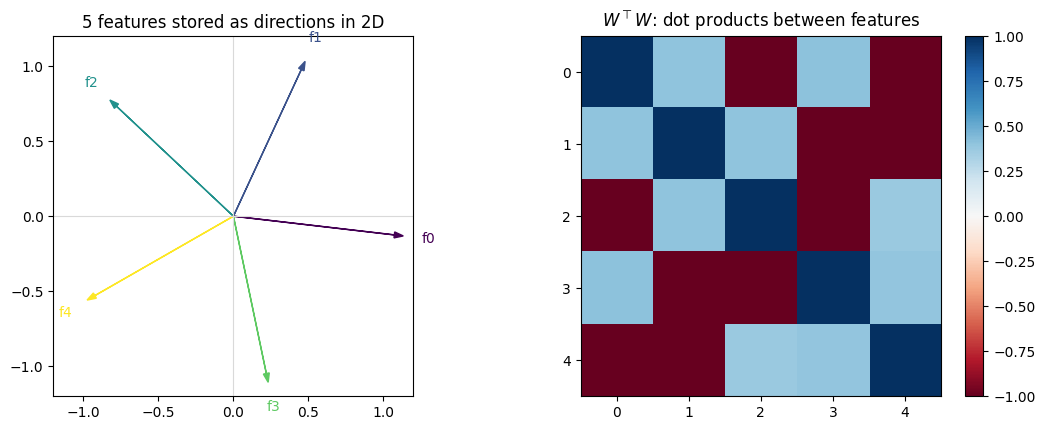

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

# (a) the 5 feature directions as 2D vectors
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for i in range(5):
    ax[0].arrow(0, 0, W[0, i], W[1, i], head_width=0.04, color=colors[i], length_includes_head=True)
    ax[0].text(W[0, i]*1.15, W[1, i]*1.15, f"f{i}", color=colors[i], ha="center", va="center")
lim = 1.2
ax[0].set_xlim(-lim, lim); ax[0].set_ylim(-lim, lim); ax[0].set_aspect("equal")
ax[0].axhline(0, color="0.85", lw=.8); ax[0].axvline(0, color="0.85", lw=.8)
ax[0].set_title("5 features stored as directions in 2D")

# (b) the interference matrix WᵀW  (off-diagonal = feature overlap)
im = ax[1].imshow(W.T @ W, cmap="RdBu", vmin=-1, vmax=1)
ax[1].set_title(r"$W^\top W$: dot products between features")
ax[1].set_xticks(range(5)); ax[1].set_yticks(range(5))
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()


The model arranges the five features as spokes of a **pentagon** (or a similar symmetric
arrangement). It cannot make them orthogonal — there are only two dimensions — so it spreads
them out to *minimise interference*: the off-diagonal entries of $W^\top W$ are small but
non-zero. This is superposition in miniature. Two consequences that matter for the rest of
the series:

- **Each axis (neuron) is polysemantic.** The x-axis has non-zero projection from several
  features at once. Reading neuron 0 tells you about a blend of features, not one.
- **Sparsity is what makes it work.** If many features were on simultaneously, the
  interference would swamp the signal. The sparser the features, the more you can pack in.
  (Try re-running with `S=0.3` — the geometry collapses toward storing just two of the
  features orthogonally (which two is arbitrary), because interference is no longer affordable.)

Real language-model activations are the same story with $d$ in the thousands and the number
of features plausibly in the *hundreds of thousands*. We can't read features off neurons.
We need to *learn the dictionary*. Enter the SAE.

Everything so far ran in the *compression* direction: we knew the sparse features and
watched them get squeezed into a dense $h$ — by hand with two features, learned with five. A
real network is the same story at scale — its activations are the dense $h$ — except nobody
hands us the sparse features that produced them. The next section runs the story backwards:
given only $h$, infer which features were active.


# How is an SAE different? Running the map backwards

Note the reuse about to happen: the compressed code $h$ of our autoencoders becomes the
**input** of the sparse autoencoder. Interpretability hands us the middle of someone else's
autoencoder — the dense activations of a trained network — and asks what is stored in there.
Let's run the whole round trip with numbers small enough to check by hand.

## The machine, up front

In case you skipped straight to this section: a sparse autoencoder is a **one-hidden-layer
autoencoder bolted onto a trained, frozen network**. Pick a layer; at every token, tap the
residual-stream activation $h \in \mathbb{R}^m$ and feed it through an encoder and a decoder:

$$
z = \operatorname{ReLU}(W_{\text{enc}} h + b_{\text{enc}}),
\qquad
\hat h = W_{\text{dec}}\, z + b_{\text{dec}},
$$

with $W_{\text{enc}} \in \mathbb{R}^{M \times m}$ and $W_{\text{dec}} \in \mathbb{R}^{m \times M}$
— and, unusually for an autoencoder, $M > m$: the hidden layer is *wider* than the input.
Training minimises reconstruction error plus a sparsity penalty,

$$
\mathcal{L} = \lVert h - \hat h \rVert_2^2 + \lambda \lVert z \rVert_1.
$$

<figure style="margin:1.8rem auto;text-align:center;max-width:900px">
<svg viewBox="0 0 860 480" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>A sparse autoencoder bolted on top of a frozen network: the residual stream runs along the bottom; the tapped activation h (3 dimensions) is expanded by the encoder into a much taller latent vector z (11 dimensions, only 2 active), then contracted by the decoder back to a reconstruction of h.</title>
<defs><marker id="arrM" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="currentColor" fill-opacity="0.55"/></marker></defs>
<text x="430" y="24" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">The machine: an SAE tapping a residual stream</text>
<line x1="15" y1="420" x2="30" y2="420" stroke="currentColor" stroke-opacity="0.35" stroke-width="1.6"/>
<line x1="125" y1="420" x2="150" y2="420" stroke="currentColor" stroke-opacity="0.35" stroke-width="1.6"/>
<line x1="245" y1="420" x2="330" y2="420" stroke="currentColor" stroke-opacity="0.35" stroke-width="1.6"/>
<line x1="425" y1="420" x2="845" y2="420" stroke="currentColor" stroke-opacity="0.35" stroke-width="1.6" marker-end="url(#arrM)"/>
<rect x="30" y="398" width="95" height="44" rx="8" fill="currentColor" fill-opacity="0.06" stroke="currentColor" stroke-opacity="0.4"/>
<text x="77.5" y="425" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.75">block ℓ−1</text>
<rect x="150" y="398" width="95" height="44" rx="8" fill="currentColor" fill-opacity="0.06" stroke="currentColor" stroke-opacity="0.4"/>
<text x="197.5" y="425" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.75">block ℓ</text>
<rect x="330" y="398" width="95" height="44" rx="8" fill="currentColor" fill-opacity="0.06" stroke="currentColor" stroke-opacity="0.4"/>
<text x="377.5" y="425" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.75">block ℓ+1</text>
<text x="645" y="408" text-anchor="middle" font-size="11" font-style="italic" fill="currentColor" opacity="0.6">residual stream (frozen network) →</text>
<circle cx="258" cy="420" r="7" fill="#4c8dd6"/>
<text x="258" y="464" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.7">tap h after block ℓ</text>
<line x1="258" y1="411" x2="258" y2="240" stroke="currentColor" stroke-opacity="0.6" stroke-width="1.8" marker-end="url(#arrM)"/>
<rect x="245" y="170" width="26" height="18" rx="3" fill="#4c8dd6"/>
<rect x="245" y="192" width="26" height="18" rx="3" fill="#4c8dd6"/>
<rect x="245" y="214" width="26" height="18" rx="3" fill="#4c8dd6"/>
<rect x="417" y="90" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="110" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="130" width="26" height="16" rx="3" fill="#f08c00"/>
<rect x="417" y="150" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="170" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="190" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="210" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="230" width="26" height="16" rx="3" fill="#f08c00"/>
<rect x="417" y="250" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="270" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="417" y="290" width="26" height="16" rx="3" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<rect x="589" y="170" width="26" height="18" rx="3" fill="#4c8dd6" fill-opacity="0.42"/>
<rect x="589" y="192" width="26" height="18" rx="3" fill="#4c8dd6" fill-opacity="0.42"/>
<rect x="589" y="214" width="26" height="18" rx="3" fill="#4c8dd6" fill-opacity="0.42"/>
<polygon points="271,170 271,232 417,306 417,90" fill="currentColor" fill-opacity="0.05" stroke="currentColor" stroke-opacity="0.22"/>
<polygon points="443,90 443,306 589,232 589,170" fill="currentColor" fill-opacity="0.05" stroke="currentColor" stroke-opacity="0.22"/>
<text x="344" y="182" text-anchor="middle" font-size="11.5" fill="currentColor">ReLU(W<tspan font-size="9" dy="3">enc</tspan><tspan dy="-3"> h + </tspan>b<tspan font-size="9" dy="3">enc</tspan><tspan dy="-3">)</tspan></text>
<text x="344" y="200" text-anchor="middle" font-size="10.5" font-style="italic" fill="currentColor" opacity="0.6">encoder — expand</text>
<text x="516" y="182" text-anchor="middle" font-size="11.5" fill="currentColor">W<tspan font-size="9" dy="3">dec</tspan><tspan dy="-3"> z + </tspan>b<tspan font-size="9" dy="3">dec</tspan><tspan dy="-3"></tspan></text>
<text x="516" y="200" text-anchor="middle" font-size="10.5" font-style="italic" fill="currentColor" opacity="0.6">decoder — contract</text>
<text x="258" y="156" text-anchor="middle" font-size="12.5" fill="currentColor">h ∈ ℝᵐ</text>
<text x="430" y="52" text-anchor="middle" font-size="12.5" fill="currentColor">z ∈ ℝᴹ</text>
<text x="430" y="70" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.65">M ≫ m, mostly zeros — bar height = dimensions</text>
<text x="602" y="156" text-anchor="middle" font-size="12.5" fill="currentColor">ĥ ∈ ℝᵐ</text>
<line x1="602" y1="238" x2="268" y2="414" stroke="currentColor" stroke-opacity="0.5" stroke-dasharray="5 4" marker-end="url(#arrM)"/>
<text x="452" y="342" text-anchor="middle" font-size="11.5" fill="currentColor">trained so ĥ ≈ h</text>
<text x="452" y="360" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.8">L = ‖h − ĥ‖₂² + λ‖z‖₁</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem;
                   max-width:70ch;margin-left:auto;margin-right:auto;text-align:left">
The network being studied runs along the bottom and stays <em>frozen</em> — the SAE is a
probe bolted on top at one chosen layer, changing nothing about the model. Bar height =
number of dimensions: the encoder (weights, bias, ReLU) <em>expands</em> the tapped
activation <em>h</em> into a latent vector <em>z</em> with far more dimensions, almost
all of them zero; the decoder contracts it back to a reconstruction ĥ. Training pushes
ĥ toward <em>h</em> while the λ‖z‖₁ term keeps <em>z</em> sparse.
</figcaption>
</figure>

Two choices should look strange after the last two sections: the middle layer is *bigger* than
the input (what kind of bottleneck is that?), and sparsity is imposed by an extra loss term
instead of being a property of the data we feed in. The rest of this section justifies both by
running one concrete example end to end.

## Step 1 — the network compresses (superposition)

Suppose the network reads text, and there are $n = 4$ semantic features it wants to track:

| | feature | fires on |
| --- | --- | --- |
| 1 | **cat** | text about cats |
| 2 | **dog** | text about dogs |
| 3 | **French** | text written in French |
| 4 | **CAPS** | TEXT WRITTEN IN ALL CAPS |

These are exactly the kind of features real language models track: each is **sparse** (most
text is not about cats) and they **co-occur freely** (a French sentence about a cat is
perfectly ordinary). But suppose the network has only $m = 2$ residual-stream dimensions to
store them in. Each feature gets a *direction* in that 2-D space; stack the four directions as
the columns of

$$
W_{\text{true}} =
\begin{pmatrix}
1 & 0 & 0.7 & 0.7\\
0 & 1 & 0.7 & -0.7
\end{pmatrix},
\qquad
d_1 = \begin{pmatrix}1\\0\end{pmatrix},\;
d_2 = \begin{pmatrix}0\\1\end{pmatrix},\;
d_3 = \begin{pmatrix}0.7\\0.7\end{pmatrix},\;
d_4 = \begin{pmatrix}0.7\\-0.7\end{pmatrix},
$$

so $d_1$ is the **cat** direction, $d_2$ the **dog** direction, $d_3$ the **French**
direction, and $d_4$ the **CAPS** direction. Four directions cannot all be orthogonal in two
dimensions — they must overlap. That is superposition again, just $4 \to 2$ instead of
$2 \to 1$.

This is the **linear representation hypothesis** from above, in miniature: each feature is
a direction, and "how active it is" is how far the activation extends along it. The best
evidence that the picture is right is that the directions can be *used*: **steering** — adding a
multiple of $d_3$ to the residual stream mid-forward-pass — makes the model behave as if the
text were more French. Directions you can push on are directions the model actually listens
to.

<figure style="margin:1.4rem auto;text-align:center;max-width:440px">
<svg viewBox="0 0 440 300" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Four named semantic directions sharing a two-dimensional residual stream, with a dashed steering extension along the French direction.</title>
<defs>
<marker id="arrS" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="currentColor" fill-opacity="0.7"/></marker>
<marker id="arrSo" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="#f08c00"/></marker>
</defs>
<text x="220" y="20" text-anchor="middle" font-size="14" font-weight="600" fill="currentColor">Four semantic directions, two residual dimensions</text>
<line x1="24" y1="190" x2="410" y2="190" stroke="currentColor" stroke-opacity="0.18"/>
<line x1="110" y1="288" x2="110" y2="42" stroke="currentColor" stroke-opacity="0.18"/>
<line x1="110" y1="190" x2="191" y2="190" stroke="currentColor" stroke-opacity="0.7" stroke-width="2" marker-end="url(#arrS)"/>
<line x1="110" y1="190" x2="110" y2="109" stroke="currentColor" stroke-opacity="0.7" stroke-width="2" marker-end="url(#arrS)"/>
<line x1="110" y1="190" x2="166" y2="135" stroke="currentColor" stroke-opacity="0.7" stroke-width="2" marker-end="url(#arrS)"/>
<line x1="110" y1="190" x2="166" y2="245" stroke="currentColor" stroke-opacity="0.7" stroke-width="2" marker-end="url(#arrS)"/>
<line x1="174" y1="127" x2="228" y2="73" stroke="#f08c00" stroke-width="1.8" stroke-dasharray="5 4" marker-end="url(#arrSo)"/>
<text x="203" y="213" text-anchor="middle" font-size="12.5" fill="currentColor">d₁ “cat”</text>
<text x="82" y="98" text-anchor="middle" font-size="12.5" fill="currentColor">d₂ “dog”</text>
<text x="182" y="146" text-anchor="start" font-size="12.5" fill="currentColor">d₃ “French”</text>
<text x="188" y="264" text-anchor="middle" font-size="12.5" fill="currentColor">d₄ “CAPS”</text>
<text x="236" y="64" text-anchor="start" font-size="11" fill="#f08c00">steer: h + α d₃</text>
<text x="236" y="80" text-anchor="start" font-size="11" fill="#f08c00" opacity="0.85">⇒ “more French”</text>
<text x="402" y="208" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.55">h¹</text>
<text x="94" y="50" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.55">h²</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.4rem;
                   max-width:60ch;margin-left:auto;margin-right:auto;text-align:left">
Four directions must share two dimensions, so they cannot all be orthogonal — that is the
geometry of superposition. Per the linear representation hypothesis, the activation at any
token is a weighted sum of whichever directions are active; pushing it further along
d₃ (dashed) steers the model toward expressing that feature more.
</figcaption>
</figure>

From here on we write $s$ for the vector of true feature activations — the $x$ of the previous
section — to emphasise that, from where we now stand, it is *hidden*. Now run the network over
the sentence *« le chat »*. At the token **chat**, the **cat** and **French** features are on;
**dog** and **CAPS** are off:

$$
s = \begin{pmatrix}1\\0\\1\\0\end{pmatrix}
\begin{matrix}\leftarrow \text{cat}\\ \leftarrow \text{dog}\\ \leftarrow \text{French}\\ \leftarrow \text{CAPS}\end{matrix}
$$

The residual-stream activation the network actually carries at that token is the sum of the
active directions:

$$
h = W_{\text{true}}\, s = d_{\text{cat}} + d_{\text{French}} =
\begin{pmatrix}1\\0\end{pmatrix} + \begin{pmatrix}0.7\\0.7\end{pmatrix} =
\begin{pmatrix}1.7\\0.7\end{pmatrix}.
$$

$$
\underbrace{\begin{pmatrix}1\\0\\1\\0\end{pmatrix}}_{\text{sparse features } s}
\;\longrightarrow\;
\underbrace{\begin{pmatrix}1.7\\0.7\end{pmatrix}}_{\text{dense activation } h}
$$

## Coordinates are not features

Look at $h = (1.7,\, 0.7)$. **Both coordinates are nonzero** — but that does *not* mean two
features are active, and the coordinates certainly don't tell you *which* ones. There is no
"cat coordinate" and no "French coordinate": the first coordinate reads $1.7$ because **cat**
contributed $1$ and **French** contributed $0.7$, and a single feature like **French**
($d_3 = (0.7,\, 0.7)$) lights up *both* coordinates on its own.

The coordinates of $h$ are just the model's internal storage basis. The sparsity claim is not
"the coordinates of $h$ are usually zero" — they usually aren't. The claim is:

> there exists a *different* set of directions ($d_{\text{cat}}, \dots, d_{\text{CAPS}}$)
> whose activation coefficients ($s$) are sparse.

The SAE's job is to find those directions.

## Step 2 — the SAE decompresses (sparse inference)

The SAE is handed only $h = (1.7,\, 0.7)$. It never sees $s$ or $W_{\text{true}}$ — it doesn't
even know the network is tracking cats. It computes the encoder–decoder pair from the top
of the section:

$$
z = \operatorname{ReLU}(W_{\text{enc}} h + b_{\text{enc}}),
\qquad
\hat h = W_{\text{dec}}\, z + b_{\text{dec}},
$$

and it is trained so that $\hat h \approx h$ while $z$ stays sparse. If training succeeds, the
columns of $W_{\text{dec}}$ converge to the true feature directions —
$W_{\text{dec}} \approx W_{\text{true}}$ — and on our example

$$
z \approx \begin{pmatrix}1\\0\\1\\0\end{pmatrix} = s,
\qquad
\hat h = W_{\text{dec}}\, z \approx d_{\text{cat}} + d_{\text{French}} = h.
$$

The SAE has *un-mixed* the activation: two numbers in, four numbers out, only two of them
nonzero. Latent 1 has become a **cat detector** and latent 3 a **French detector** — each
nonzero latent names one feature, which is exactly the kind of labelled, monosemantic latent
you will browse on the Neuronpedia dashboard in [Part 3](03_neuronpedia_dashboard.ipynb).


<figure style="margin:1.8rem auto;max-width:1000px">
  <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(330px,1fr));
              gap:1.2rem 1.8rem;align-items:center">
    <div>
<svg viewBox="0 0 420 340" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Four feature directions in a two-dimensional residual stream; the activation h is the sum of the two active directions.</title>
<defs>
<marker id="arrO" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="#f08c00"/></marker>
<marker id="arrB" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="#4c8dd6"/></marker>
<marker id="arrG" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="currentColor" fill-opacity="0.45"/></marker>
</defs>
<text x="210" y="22" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">Four feature directions, two dimensions</text>
<!-- axes -->
<line x1="24" y1="210" x2="400" y2="210" stroke="currentColor" stroke-opacity="0.18"/>
<line x1="110" y1="322" x2="110" y2="46" stroke="currentColor" stroke-opacity="0.18"/>
<!-- inactive directions d2, d4 -->
<line x1="110" y1="210" x2="110" y2="129" stroke="currentColor" stroke-opacity="0.45" marker-end="url(#arrG)"/>
<line x1="110" y1="210" x2="167" y2="266" stroke="currentColor" stroke-opacity="0.45" marker-end="url(#arrG)"/>
<text x="80" y="120" text-anchor="middle" font-size="12.5" fill="currentColor" opacity="0.6">d₂ “dog”</text>
<text x="184" y="282" text-anchor="middle" font-size="12.5" fill="currentColor" opacity="0.6">d₄ “CAPS”</text>
<!-- active directions d1, d3 -->
<line x1="110" y1="210" x2="191" y2="210" stroke="#f08c00" stroke-width="2.4" marker-end="url(#arrO)"/>
<line x1="110" y1="210" x2="166" y2="155" stroke="#f08c00" stroke-width="2.4" marker-end="url(#arrO)"/>
<text x="163" y="230" text-anchor="middle" font-size="12.5" font-weight="600" fill="#f08c00">d₁ “cat”</text>
<text x="152" y="141" text-anchor="middle" font-size="12.5" font-weight="600" fill="#f08c00">d₃ “French”</text>
<!-- tip-to-tail sum: d3 translated to tip of d1 -->
<line x1="195" y1="210" x2="251" y2="156" stroke="#f08c00" stroke-width="1.6" stroke-dasharray="5 4" stroke-opacity="0.75" marker-end="url(#arrO)"/>
<text x="238" y="196" text-anchor="middle" font-size="11.5" fill="#f08c00" opacity="0.85">+ d₃</text>
<!-- h -->
<line x1="110" y1="210" x2="250" y2="152" stroke="#4c8dd6" stroke-width="3.2" marker-end="url(#arrB)"/>
<circle cx="255" cy="150" r="4.5" fill="#4c8dd6"/>
<text x="272" y="134" text-anchor="start" font-size="13" font-weight="600" fill="#4c8dd6">h = d₁ + d₃</text>
<text x="272" y="151" text-anchor="start" font-size="12" fill="#4c8dd6" opacity="0.85">= “cat” + “French”</text>
<text x="272" y="168" text-anchor="start" font-size="12" fill="#4c8dd6" opacity="0.85">= (1.7, 0.7)</text>
<!-- axis labels -->
<text x="392" y="228" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.55">h¹</text>
<text x="94" y="54" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.55">h²</text>
<text x="210" y="336" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">both coordinates of h are nonzero — yet only “cat” and “French” are actually on</text>
</svg>
    </div>
    <div>
<svg viewBox="0 0 540 340" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Round trip with numbers: sparse features (1,0,1,0) become the dense activation (1.7,0.7); the SAE infers sparse latents (1,0,1,0) and reconstructs the activation.</title>
<defs>
<marker id="arrF" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L10,5 L0,10 z" fill="currentColor" fill-opacity="0.55"/></marker>
</defs>
<text x="270" y="22" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">The round trip, with numbers</text>
<!-- s column (4 cells) -->
<g font-size="13" font-weight="600" text-anchor="middle">
<rect x="42" y="100" width="44" height="34" rx="6" fill="#f08c00"/><text x="64" y="122" fill="#fff">1</text>
<rect x="42" y="138" width="44" height="34" rx="6" fill="none" stroke="currentColor" stroke-opacity="0.4"/><text x="64" y="160" fill="currentColor" opacity="0.5" font-weight="400">0</text>
<rect x="42" y="176" width="44" height="34" rx="6" fill="#f08c00"/><text x="64" y="198" fill="#fff">1</text>
<rect x="42" y="214" width="44" height="34" rx="6" fill="none" stroke="currentColor" stroke-opacity="0.4"/><text x="64" y="236" fill="currentColor" opacity="0.5" font-weight="400">0</text>
</g>
<text x="64" y="282" text-anchor="middle" font-size="13" fill="currentColor">s</text>
<text x="64" y="299" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">sparse features</text>
<text x="64" y="312" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">(hidden from us)</text>
<g font-size="9.5" text-anchor="end" fill="currentColor" opacity="0.65">
<text x="36" y="121">cat</text><text x="36" y="159">dog</text><text x="36" y="197">French</text><text x="36" y="235">CAPS</text>
</g>
<!-- arrow 1 -->
<line x1="94" y1="174" x2="158" y2="174" stroke="currentColor" stroke-opacity="0.55" stroke-width="1.6" marker-end="url(#arrF)"/>
<text x="127" y="160" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.7">the network</text>
<text x="127" y="192" text-anchor="middle" font-size="10.5" font-style="italic" fill="currentColor" opacity="0.7">superposition</text>
<!-- h column (2 cells) -->
<g font-size="13" font-weight="600" text-anchor="middle">
<rect x="168" y="138" width="52" height="34" rx="6" fill="#4c8dd6"/><text x="194" y="160" fill="#fff">1.7</text>
<rect x="168" y="176" width="52" height="34" rx="6" fill="#4c8dd6"/><text x="194" y="198" fill="#fff">0.7</text>
</g>
<text x="194" y="282" text-anchor="middle" font-size="13" fill="currentColor">h = W<tspan font-size="9" dy="3">true</tspan><tspan dy="-3"> s</tspan></text>
<text x="194" y="299" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">dense activation</text>
<text x="194" y="312" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">(all the SAE sees)</text>
<!-- arrow 2 -->
<line x1="228" y1="174" x2="292" y2="174" stroke="currentColor" stroke-opacity="0.55" stroke-width="1.6" marker-end="url(#arrF)"/>
<text x="261" y="160" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.7">W<tspan font-size="8" dy="2">enc</tspan><tspan dy="-2">, ReLU</tspan></text>
<text x="261" y="192" text-anchor="middle" font-size="10.5" font-style="italic" fill="currentColor" opacity="0.7">sparse inference</text>
<!-- z column (4 cells) -->
<g font-size="13" font-weight="600" text-anchor="middle">
<rect x="302" y="100" width="44" height="34" rx="6" fill="#f08c00"/><text x="324" y="122" fill="#fff">1</text>
<rect x="302" y="138" width="44" height="34" rx="6" fill="none" stroke="currentColor" stroke-opacity="0.4"/><text x="324" y="160" fill="currentColor" opacity="0.5" font-weight="400">0</text>
<rect x="302" y="176" width="44" height="34" rx="6" fill="#f08c00"/><text x="324" y="198" fill="#fff">1</text>
<rect x="302" y="214" width="44" height="34" rx="6" fill="none" stroke="currentColor" stroke-opacity="0.4"/><text x="324" y="236" fill="currentColor" opacity="0.5" font-weight="400">0</text>
</g>
<text x="324" y="282" text-anchor="middle" font-size="13" fill="currentColor">z ≈ s</text>
<text x="324" y="299" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">SAE latents</text>
<text x="324" y="312" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">(sparse again!)</text>
<!-- arrow 3 -->
<line x1="354" y1="174" x2="418" y2="174" stroke="currentColor" stroke-opacity="0.55" stroke-width="1.6" marker-end="url(#arrF)"/>
<text x="387" y="160" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.7">W<tspan font-size="8" dy="2">dec</tspan></text>
<text x="387" y="192" text-anchor="middle" font-size="10.5" font-style="italic" fill="currentColor" opacity="0.7">reconstruct</text>
<!-- h-hat column (2 cells) -->
<g font-size="13" font-weight="600" text-anchor="middle">
<rect x="428" y="138" width="52" height="34" rx="6" fill="#4c8dd6" fill-opacity="0.42"/><text x="454" y="160" fill="currentColor">1.7</text>
<rect x="428" y="176" width="52" height="34" rx="6" fill="#4c8dd6" fill-opacity="0.42"/><text x="454" y="198" fill="currentColor">0.7</text>
</g>
<text x="454" y="282" text-anchor="middle" font-size="13" fill="currentColor">ĥ ≈ h</text>
<text x="454" y="299" text-anchor="middle" font-size="10.5" fill="currentColor" opacity="0.62">reconstruction</text>
<!-- brace hint: 4 -> 2 -> 4 -->
<text x="270" y="72" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">4 features → 2 dims → 4 latents → 2 dims: the SAE is <tspan font-style="italic">wider</tspan> than its input</text>
</svg>
    </div>
  </div>
  <figcaption style="font-size:0.9em;opacity:0.75;margin-top:0.9rem;
                     max-width:70ch;margin-left:auto;margin-right:auto;text-align:left">
    <strong>Left:</strong> four feature directions d₁…d₄ share a two-dimensional residual
    stream, so they cannot all be orthogonal — that is superposition. On this input — the token <em>chat</em> in a French sentence — only
    d₁ (“cat”) and d₃ (“French”) are active (orange), and the network's activation is their sum
    <em>h</em> = (1.7, 0.7). Both <em>coordinates</em> of <em>h</em> are nonzero even though
    only two of the four <em>features</em> are on: coordinates are not features.
    <strong>Right:</strong> the same story as a pipeline. The network turns sparse
    <em>s</em> into dense <em>h</em>; the SAE, seeing only <em>h</em>, infers sparse latents
    <em>z</em> ≈ <em>s</em> and reconstructs ĥ ≈ <em>h</em>;
    latent 1 has become a “cat” detector, latent 3 a “French” detector. Its latent layer is wider than
    its input — the bottleneck is sparsity, not dimension.
  </figcaption>
</figure>


## Why the SAE latent space is *bigger*, not smaller

Notice the shape of the round trip. The network went $4 \to 2$ ($n$ features into $m < n$
dimensions), so the SAE must go $2 \to 4$: it needs **more latents than input dimensions**,
$M > m$ — one latent per feature it hopes to recover. A real SAE is the same picture scaled
up: in [Part 4](04_train_jumprelu_gemma3_1b.ipynb) we expand Gemma's $m = 1152$ residual dimensions into $M = 16384$ latents,
each of which we hope is as nameable as “cat” or “French” — in [Part 3](03_neuronpedia_dashboard.ipynb) you will meet one
that fires on fruit.

So an SAE is an **overcomplete** autoencoder. Its bottleneck is not "fewer numbers" — it has
*more* numbers than its input. Its bottleneck is that **most latents must be zero**: an
information bottleneck made of sparsity rather than dimensionality.

## What actually creates the sparsity?

Nothing in $z = \operatorname{ReLU}(W_{\text{enc}} h + b_{\text{enc}})$ forces $z$ to be
sparse. An overcomplete dictionary offers many ways to write $\hat h \approx h$, and most of
them smear the job across lots of small, dense activations. The ReLU only *permits* sparsity:
it lets a latent sit at exactly zero and keeps the rest non-negative.

What *rewards* sparsity is an explicit term in the loss:

$$
\mathcal{L} =
\underbrace{\lVert h - \hat h \rVert_2^2}_{\text{reconstruct } h}
\;+\;
\lambda\, \underbrace{\lVert z \rVert_1}_{\text{use few latents}}.
$$

The two terms fight. Reconstruction says "use enough latents to rebuild $h$"; the $L_1$
penalty makes every nonzero latent cost something, so reconstruction accuracy must *pay* for
each latent it turns on. (Parts 1–2 replace the $L_1$ term with better mechanisms — TopK,
JumpReLU — but the tug-of-war is the same.)

### Aside — a preview of JumpReLU

There is a subtler problem that a plain ReLU cannot fix, visible right here in our example.
Take the most natural encoder — score each feature by dot product with its direction,
$a_i = d_i^\top h$ — and run it on $h = d_1 + d_3$:

$$
a = W_{\text{true}}^\top h = (1.70,\;\; 0.70,\;\; 1.68,\;\; 0.70).
$$

**Every score is positive**, so ReLU keeps all four: **dog** and **CAPS** appear to fire on a
French sentence about a cat. Because the four directions overlap, active features *leak* into
inactive detectors — and this time the leakage lands on the positive side, where clipping
negatives does nothing. (Contrast the previous section, where the antipodal $\pm 1$ embedding
conveniently made all interference negative.)

What separates truth from leakage here is not sign but **size**: active scores $\approx 1.7$,
leakage $= 0.7$. A ReLU with a per-latent *threshold* — exactly zero below $\theta$, **full
value** above it —

$$
\operatorname{JumpReLU}_\theta(a_i) = a_i \cdot \mathbb{1}[a_i > \theta]
$$

with any $\theta$ between $0.7$ and $1.68$ returns $(1.70,\; 0,\; 1.68,\; 0)$: the right two
features, at full strength. That is **JumpReLU**, the activation GemmaScope uses.
[Part 2](02_architectures_jumprelu.ipynb) shows why the threshold must be *learned*, and why
keeping the full value (rather than subtracting $\theta$) matters.

<figure style="margin:1rem auto 0.2rem;text-align:center;max-width:620px">
<svg viewBox="0 0 640 252" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>ReLU passes every positive score including the 0.7 leakage; JumpReLU with threshold 1 zeroes scores below the threshold and passes 1.7 through at full value.</title>
<text x="140" y="24" text-anchor="middle" font-size="12.5" font-weight="600" fill="currentColor">ReLU — keeps every positive score</text>
<text x="460" y="24" text-anchor="middle" font-size="12.5" font-weight="600" fill="currentColor">JumpReLU — off below θ, full value above</text>
<line x1="30" y1="205" x2="250" y2="205" stroke="currentColor" stroke-opacity="0.3"/>
<line x1="75" y1="210" x2="75" y2="46" stroke="currentColor" stroke-opacity="0.3"/>
<polyline points="30,205 75,205 228,52" fill="none" stroke="#4c8dd6" stroke-width="2.4"/>
<circle cx="135" cy="146" r="4.5" fill="currentColor" opacity="0.55"/>
<text x="144" y="150" text-anchor="start" font-size="10.5" fill="currentColor" opacity="0.7">0.7 leaks through</text>
<circle cx="220" cy="61" r="4.5" fill="#f08c00"/>
<text x="212" y="52" text-anchor="end" font-size="10.5" fill="#f08c00">1.7</text>
<line x1="350" y1="205" x2="570" y2="205" stroke="currentColor" stroke-opacity="0.3"/>
<line x1="395" y1="210" x2="395" y2="46" stroke="currentColor" stroke-opacity="0.3"/>
<line x1="350" y1="205" x2="480" y2="205" stroke="#f08c00" stroke-width="2.4"/>
<line x1="480" y1="203" x2="480" y2="122" stroke="currentColor" stroke-opacity="0.3" stroke-dasharray="4 3"/>
<line x1="480" y1="120" x2="548" y2="52" stroke="#f08c00" stroke-width="2.4"/>
<circle cx="480" cy="205" r="3.5" fill="#f08c00"/>
<circle cx="480" cy="120" r="3.5" fill="none" stroke="#f08c00" stroke-width="1.6"/>
<line x1="480" y1="205" x2="480" y2="212" stroke="currentColor" stroke-opacity="0.6"/>
<text x="480" y="228" text-anchor="middle" font-size="11.5" fill="currentColor">θ = 1</text>
<circle cx="455" cy="205" r="4.5" fill="currentColor" opacity="0.55"/>
<text x="450" y="188" text-anchor="end" font-size="10.5" fill="currentColor" opacity="0.7">0.7 → 0</text>
<circle cx="540" cy="61" r="4.5" fill="#f08c00"/>
<text x="532" y="52" text-anchor="end" font-size="10.5" fill="#f08c00">1.7 → 1.7</text>
<text x="140" y="245" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.6">score a</text>
<text x="460" y="245" text-anchor="middle" font-size="11" fill="currentColor" opacity="0.6">score a</text>
</svg>
</figure>

## The two networks, side by side again


This is the comparison the opening figure promised:

| | Bottleneck autoencoder (toy model) | Sparse autoencoder |
| --- | --- | --- |
| **Input** | sparse ground-truth features $s$ | dense network activation $h$ |
| **Middle layer** | *narrower* than input ($m < n$) | *wider* than input ($M > m$) |
| **What limits it** | dimension | sparsity penalty (most $z_i = 0$) |
| **Role of the ReLU** | clips negative interference in the output | permits exact zeros in the latents |
| **Shows** | how superposition arises | how to undo it |

$$
\boxed{\;\text{sparse features } s
\;\overset{\text{superposition (the network)}}{\longrightarrow}\;
\text{dense activation } h
\;\overset{\text{sparse inference (the SAE)}}{\longrightarrow}\;
\text{sparse latents } z \approx s\;}
$$

That reversal is the entire reason SAEs exist.

One promise is still open: we *claimed* a trained SAE recovers the true
directions. Time to prove it — with the field's actual parametrization, on a
dictionary we control.


# Proving it: train an SAE against a known dictionary

## The full anatomy (what GemmaScope actually parametrises)

Two renames and two new ingredients before we train for real. The walkthrough's latents
$z$ are called $\mathbf{f}$ from here on (the standard name), and the production
parametrization adds a learned centre $\mathbf{b}_{\text{dec}}$ and unit-norm dictionary
rows.

An SAE is a second, wider autoencoder that we bolt onto a *frozen* model's activations. It
does not change the model; it just learns to re-express each activation vector $\mathbf{x}$
as a sparse combination of dictionary directions. The architecture:

$$
\begin{aligned}
\text{encode:}\quad \mathbf{f} &= \sigma\!\big(W_{\text{enc}}(\mathbf{x}-\mathbf{b}_{\text{dec}}) + \mathbf{b}_{\text{enc}}\big) \\
\text{decode:}\quad \hat{\mathbf{x}} &= \mathbf{b}_{\text{dec}} + \sum_i f_i\, \mathbf{d}_i \quad(\mathbf{d}_i = \text{row } i \text{ of } W_{\text{dec}})
\end{aligned}
$$

- $\mathbf{x} \in \mathbb{R}^{d_{\text{model}}}$ is one activation vector (e.g. a residual-stream
  vector at some layer and token).
- $\mathbf{f} \in \mathbb{R}^{d_{\text{sae}}}$ are the **latents** (a.k.a. features), with
  $d_{\text{sae}} \gg d_{\text{model}}$ — the dictionary is **overcomplete**. GemmaScope uses
  $d_{\text{model}}=1152$ and $d_{\text{sae}}=16384$ (a 14× expansion).
- The **rows of $W_{\text{dec}}$** are the dictionary directions $\mathbf{d}_i$. They're held to
  **unit norm**, so all the "how strongly is this feature present" information lives in
  $\mathbf{f}$, not in the vector lengths.
- $\sigma$ keeps latents **non-negative** — ReLU to start, JumpReLU in Part 2 — so they can sit at
  exactly zero. The *sparsity* itself comes from the loss below, not from $\sigma$.
- $\mathbf{b}_{\text{dec}}$ is subtracted before encoding and added back after — it acts as a
  learned "center" for the activations.

We train it on a single objective: **reconstruct $\mathbf{x}$ using as few active latents as
possible.**


<figure style="margin:1.6rem auto;text-align:center;max-width:720px">
<svg viewBox="0 0 680 384" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<text x="340" y="24" text-anchor="middle" font-size="15" font-weight="600" fill="currentColor">Sparse autoencoder — an overcomplete dictionary where only a few latents fire</text>
<line x1="123" y1="95" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="356" y1="288" x2="562" y2="95" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="288" x2="562" y2="150" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="288" x2="562" y2="205" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="288" x2="562" y2="260" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="95" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="150" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="205" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="260" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="95" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="150" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="205" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="260" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<circle cx="110" cy="95" r="13" fill="#4c8dd6"/>
<circle cx="110" cy="150" r="13" fill="#4c8dd6"/>
<circle cx="110" cy="205" r="13" fill="#4c8dd6"/>
<circle cx="110" cy="260" r="13" fill="#4c8dd6"/>
<circle cx="345" cy="40" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="71" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="102" r="11" fill="#f08c00"/>
<circle cx="345" cy="133" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="164" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="195" r="11" fill="#f08c00"/>
<circle cx="345" cy="226" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="257" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="288" r="11" fill="#f08c00"/>
<circle cx="345" cy="319" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="575" cy="95" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="575" cy="150" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="575" cy="205" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="575" cy="260" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<text x="110" y="305" text-anchor="middle" font-size="14" fill="currentColor">activation  x</text>
<text x="110" y="323" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">d_model = 4</text>
<text x="345" y="352" text-anchor="middle" font-size="14" fill="currentColor">latents  f</text>
<text x="345" y="370" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">d_sae ≫ d_model · sparse</text>
<text x="575" y="305" text-anchor="middle" font-size="14" fill="currentColor">x̂ = b + Σ fᵢ dᵢ</text>
<text x="575" y="323" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">from a few atoms</text>
<circle cx="500" cy="52" r="6" fill="#f08c00"/><text x="512" y="56" font-size="12" fill="currentColor">active latent</text>
<circle cx="500" cy="72" r="5" fill="none" stroke="currentColor" stroke-opacity="0.4"/><text x="512" y="76" font-size="12" fill="currentColor" opacity="0.75">inactive</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem">The SAE of §3. The dictionary is <em>overcomplete</em> (d_sae&nbsp;≫&nbsp;d_model), so the encoder fans a 4-dim activation out to many latents — but only a handful are non-zero (orange). Reconstruction is the sum of just those few decoder directions (the bold orange edges), which is why <em>x̂ = b + Σ fᵢ dᵢ</em> stays sparse.</figcaption>
</figure>


## L0 vs L1: the central tension

The loss is the one we've been using all along — reconstruction plus $\lambda\lVert\mathbf{f}\rVert_1$. The $L_1$ term pushes activations toward zero, and because the $L_1$ ball has corners, the minimum tends to land on solutions where most $f_i$ are **exactly** zero.

Why $L_1$ and not "count the non-zeros"? Because the thing we actually care about is the
**$L_0$ "norm"** — the *number* of active latents:

$$\lVert \mathbf{f}\rVert_0 \;=\; \#\{i : f_i \neq 0\}.$$

$L_0$ is exactly "how many features fired", which is what interpretability cares about — but
it's piecewise-constant, so its gradient is zero almost everywhere and useless for training.
$L_1$ is the convex surrogate whose gradient is non-zero almost everywhere and *does* induce sparsity. This gap
between "the $L_0$ we want" and "the $L_1$ we can optimise" is the single most important
tension in SAE design, and it's what motivates JumpReLU in Part 2. **Remember the phrase
"L0" — on the Neuronpedia dashboard it's the average number of latents active per token, and
it's the headline number for how interpretable an SAE is.**


## Watching an SAE recover features from superposition

To *prove* the SAE does what we claim, we need ground truth, so we generate activations from a
**known** dictionary (these activations play the role of the toy model's bottleneck $\mathbf{h}$
from the pentagon experiment — the compressed vector an SAE actually sees).

Setup: $n_{\text{true}}=32$ ground-truth feature directions in a $d=16$-dim space (genuinely in
superposition, $32 > 16$). Each data point turns on ~3 random features with known positive
magnitudes and sums their directions — precisely the generative model the SAE assumes, so a good
SAE should rediscover the 32.


In [6]:
torch.manual_seed(0)
d, n_true, d_sae = 16, 32, 64
D_true = F.normalize(torch.randn(n_true, d), dim=-1)   # ground-truth dictionary (unit rows)
p_active = 3.0 / n_true                                 # ~3 active features per example

def gen(batch):
    mask = (torch.rand(batch, n_true) < p_active).float()
    mags = (0.5 + torch.rand(batch, n_true)) * mask     # magnitude ~ U(0.5, 1.5) when ON
    return mags @ D_true, mags                          # x = sum of active feature directions

class ReLUSAE(nn.Module):
    def __init__(self, d_model, d_sae):
        super().__init__()
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.W_enc = nn.Parameter(torch.randn(d_model, d_sae) / np.sqrt(d_model))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(F.normalize(torch.randn(d_sae, d_model), dim=-1))
    @torch.no_grad()
    def normalize_decoder(self):
        self.W_dec.data = F.normalize(self.W_dec.data, dim=-1)
    def forward(self, x):
        f = F.relu((x - self.b_dec) @ self.W_enc + self.b_enc)   # encode (ReLU)
        return f @ self.W_dec + self.b_dec, f                    # decode

def train_relu_sae(sae, l1=0.4, steps=2000, batch=4096, lr=4e-3):
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    for _ in range(steps):
        x, _ = gen(batch)
        x_hat, f = sae(x)
        loss = ((x_hat - x) ** 2).sum(-1).mean() + l1 * f.abs().sum(-1).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        sae.normalize_decoder()          # keep dictionary directions unit-norm
    return sae

sae = train_relu_sae(ReLUSAE(d, d_sae))

# how many active latents per example (L0), and reconstruction quality (FVU)?
x, mags = gen(8192)
x_hat, f = sae(x)
L0  = (f > 1e-6).float().sum(-1).mean().item()
FVU = (((x_hat - x) ** 2).sum() / ((x - x.mean(0)) ** 2).sum()).item()
print(f"L0 (avg active latents) = {L0:.2f}   (true value ~ {p_active*n_true:.1f})")
print(f"FVU (fraction of variance unexplained) = {FVU:.3f}   ->  {1-FVU:.1%} of variance explained")


L0 (avg active latents) = 8.71   (true value ~ 3.0)
FVU (fraction of variance unexplained) = 0.125   ->  87.5% of variance explained


72% of the 32 true features recovered with cosine > 0.9


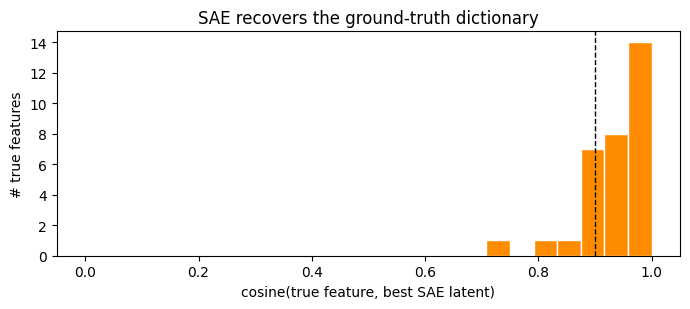

In [7]:
# Did we recover the true dictionary? Match each true feature to its best SAE latent by cosine.
cos = F.normalize(D_true, dim=-1) @ F.normalize(sae.W_dec.detach(), dim=-1).T   # (n_true, d_sae)
best_cos = cos.max(dim=1).values
recovered = (best_cos > 0.9).float().mean().item()
print(f"{recovered:.0%} of the {n_true} true features recovered with cosine > 0.9")

plt.figure(figsize=(7, 3.2))
plt.hist(best_cos.numpy(), bins=24, range=(0, 1), color="darkorange", edgecolor="white")
plt.axvline(0.9, color="k", ls="--", lw=1); plt.xlabel("cosine(true feature, best SAE latent)")
plt.ylabel("# true features"); plt.title("SAE recovers the ground-truth dictionary")
plt.tight_layout(); plt.show()


About three-quarters of the true directions come back with cosine > 0.9 — the SAE has
largely **un-mixed the superposition**, turning polysemantic 16-dimensional vectors into a
mostly-monosemantic 64-latent code. That's the whole game — though not played perfectly: it
spends ~9 latents per example where the true answer is ~3.

Two things to notice, because they're the seeds of Part 2:

- **L0 is measured, not set.** We chose $\lambda$ (the $L_1$ coefficient) and *observed* an
  L0 of ~9 — three times the true count. To hit a *target* L0 you have to hunt for the right
  $\lambda$. JumpReLU will let us target L0 directly.
- **Not every true feature is recovered perfectly**, and some SAE latents are duplicates or
  dead. Both are real failure modes we'll meet again.


## The metrics that grade an SAE

Three numbers summarise any SAE, and you'll see all three throughout the series:

| Metric | Definition | What it tells you |
|---|---|---|
| **L0** | avg. number of latents active per token, $\mathbb{E}\lVert\mathbf{f}\rVert_0$ | sparsity / interpretability. Lower = each token explained by fewer features. GemmaScope's layer-13 SAE targets **L0 ≈ 60**. |
| **Reconstruction** (FVU / variance explained) | $\mathbb{E}\lVert\mathbf{x}-\hat{\mathbf{x}}\rVert_2^2 / \mathbb{E}\lVert\mathbf{x}-\bar{\mathbf{x}}\rVert_2^2$ | fidelity. How much of the activation the SAE captures. |
| **Loss recovered** (CE / delta) | how much of the model's next-token loss survives when you *replace* $\mathbf{x}$ with $\hat{\mathbf{x}}$ | fidelity *that matters to the model* — a reconstruction can look good in MSE but still hurt the model's predictions. We'll compute this on real Gemma in Part 4. |

L0 and reconstruction are in fundamental **tension**: driving L0 down (fewer active latents)
always costs reconstruction. Every SAE lives somewhere on this Pareto frontier, and the whole
point of better architectures (Part 2) is to push the frontier outward — same reconstruction
at lower L0.

Two more diagnostics worth knowing:

- **Dead latents** — latents that (almost) never fire on any input. Wasted dictionary capacity;
  training tricks like *resampling* revive them.
- **Feature density** — for each latent, the fraction of tokens it fires on. This is literally
  the "activation density" number on the dashboard, and we'll compute it for the fruit feature
  in Part 3.


# Where we are

Everything the rest of the series leans on, in six lines:

1. a **linear** bottleneck autoencoder can only project onto its top-$m$ principal subspace —
   it cannot store more features than dimensions;
2. a **ReLU** lets a bottleneck exploit *sparsity* to store more features than dimensions,
   paying only when features co-fire — that is **superposition**, and it is why neurons are
   polysemantic and features are *directions* we must learn;
3. a **sparse autoencoder** runs the process in reverse: an overcomplete dictionary trained
   with **reconstruction + a sparsity penalty**, whose decoder rows are the learned feature
   directions;
4. it *works*, imperfectly: on a known dictionary, a plain ReLU SAE recovers ~72% of the
   true directions at cosine > 0.9, while overspending latents (L0 ≈ 9 vs a true ~3) —
   exactly the slack better architectures close;
5. the sparsity we *care* about is **L0** (a count); the penalty we can *train* is **L1** —
   that mismatch, plus the way $L_1$ drags down the very latents that *should* fire
   (**shrinkage**), is the theme of Part 2;
6. an SAE is graded on **L0**, **reconstruction (FVU)**, and **loss recovered**, and lives on
   an L0-versus-fidelity frontier that better architectures push outward.

**Next → [Part 2: SAE architectures & JumpReLU](02_architectures_jumprelu.ipynb)** — TopK,
Gated, and the JumpReLU activation GemmaScope actually uses, with its
straight-through-estimator gradients implemented by hand.
